This notebook provides some examples on two-qubit tomography. 

## Initialization

### Imports

First, we'll do the meeded imports. Note that library's .py files are directly accessed from the folder `solver`.

In [2]:
from os import path
import warnings
assert path.exists("solver") 
assert path.exists("solver/utils")

In [3]:
#%pip install -r requirements.txt

In [5]:
with warnings.catch_warnings():
    import tensorflow as tf  # tf 2.x
    import tensornetwork as tn
    tn.set_default_backend("tensorflow")
    
import numpy as np
import QGOpt as qgo
import math
import matplotlib.pyplot as plt

import solver.utils.general_utils as util
import solver.noising_tools as ns
import solver.utils.channel_utils as c_util
import solver.file_management as fm
import solver.circuits_generation as cg

from solver.QCCalc import QCEvaluator
from solver.experiments import ExperimentConductor, assert_psi2_eq_1
from solver.utils.misc import unwrap_dict, NconTemplate, INT, FLOAT, COMPLEX, ID_GATE
from solver.QCSolver import QGOptSolver, get_complex_channel_form, QGOptSolverDebug

### Quantum gates preparation

Let us conduct a simple experiment which makes quantum tomography of gates $\sf RX$, $\sf RY$ and $\sf CX$. $\sf RX$ and $\sf RY$ represent unitary rotations with angle $\pi/2$, while $\sf CX$ represents the controlled NOT gate. These quantum gates can be expressed as unitary operators as follows:
$$
{\sf RX} =  \begin{bmatrix}
            \cos(\pi/4) & -\imath \sin(\pi/4)\\
            -\imath \sin(\pi/4) & \cos(\pi/4)
        \end{bmatrix},  
{\sf RY} =  \begin{bmatrix}
            \cos(\pi/4) & -\sin(\pi/4)\\
            \sin(\pi/4) & \cos(\pi/4)
        \end{bmatrix},
{\sf CX} =      
    \begin{bmatrix}
        1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0
    \end{bmatrix}.
$$

We will also need an identity matrix: both for providiing a fictionary measurement gate (SPAM operation) and for internal purposes.

In [7]:
dim=2

In [10]:
Rx = util.generalized_rotation_x(math.pi/2, dim)
Ry = util.generalized_rotation_x(math.pi/2, dim)
print('Rx:', Rx.numpy().round(3))
print('Ry:', Ry.numpy().round(3))

E = tf.eye(2, dtype=COMPLEX)

Rx: [[0.707+0.j    0.   -0.707j]
 [0.   -0.707j 0.707+0.j   ]]
Ry: [[0.707+0.j    0.   -0.707j]
 [0.   -0.707j 0.707+0.j   ]]


In [11]:
CX_44 = tf.constant([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, 1, 0]], dtype=COMPLEX)

Noise_CX = tf.constant([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 1, 0],
                     [0, 0, 0, 1]], dtype=COMPLEX)

In [16]:
CX = util.convert_44_to_2222(CX_44, dim)
Noise_CX = util.convert_44_to_2222(Noise_CX, dim)

Rx_channel = c_util.convert_1qmatrix_to_channel(Rx)
Ry_channel = c_util.convert_1qmatrix_to_channel(Ry)
E_channel = c_util.convert_1qmatrix_to_channel(E)
U_channel = c_util.convert_1qmatrix_to_channel(E)
CX_channel = c_util.convert_2qmatrix_to_channel(CX, dim)
Noise_CX_channel = c_util.convert_2qmatrix_to_channel(Noise_CX, dim)

In [17]:
default_pure_channels = {'Rx':Rx_channel,
                         'Ry':Ry_channel,
                         'M': E_channel,
                         ID_GATE:E_channel,
                         'CX': CX_channel,
                         'Noise-CX': Noise_CX_channel}                        

### Circuits preparation

In [18]:
NUM_QUBITS = 2

gates_labels = list(default_pure_channels.keys())
gates_labels.remove(ID_GATE)

gen = cg.DataGenerator(qubits_num=NUM_QUBITS,
                       gates_names=gates_labels,
                       single_qub_gates_num=3,
                       two_qub_gates_num=2)

In [19]:
def gen_circs_without_CX():
    preps = [[],
             ['Rx_0', 'Rx_1'],
             ['Ry_0', 'Ry_1'],
             ['Rx_0', 'Rx_0', 'Rx_1', 'Rx_1']]
    
    toms = [[],
            ['Rx_0', 'Rx_1'],
            ['Ry_0', 'Ry_1']]
    
    meass = [['M_0', 'M_1'],
             ['Rx_0', 'Rx_1', 'M_0', 'M_1'],
             ['Ry_0', 'Ry_1', 'M_0', 'M_1']]
    
    ans = []
    
    for prep in preps:
        for tom in toms:
            for meas in meass:
                ans.append(prep + tom + meas)
                
    return ans

circs1 = gen_circs_without_CX()

In [20]:
def gen_circs_with_CX():
    preps_0 = [[],
               ['Rx_0'],
               ['Ry_0'],
               ['Rx_0', 'Rx_0']]
    preps_1 = [[],
               ['Rx_1'],
               ['Ry_1'],
               ['Rx_1', 'Rx_1']]
    
    meas_0 = [['M_0'],
              ['Rx_0', 'M_0'],
              ['Ry_0', 'M_0']]
    meas_1 = [['M_1'],
              ['Rx_1', 'M_1'],
              ['Ry_1', 'M_1']]
    
    ans = []
    tup_ans = []
    
    for prep_0 in preps_0:
        for prep_1 in preps_1:
            for m_0 in meas_0:
                for m_1 in meas_1:
                    ans.append(prep_0 + prep_1 + ['CX_0_1', 'Noise-CX_0_1'] + m_0 + m_1)
                
    return ans

circs2 = gen_circs_with_CX()

#circs = circs1 + circs2
circs = circs2 # use only 2qub circs for CX estimation
print(len(circs))

144


In [21]:
np.random.seed(1337)

ncon_tmpls = gen.get_tmpl_dict_from_human_circs(circs + [[]])  # add an empty circuit

for idx in np.random.choice(np.arange(len(circs)), 3):
    print(f'A quantum circuit with very simple "human" representation \n{circs[idx]}'
    f'\nhas a very scary tensor network template \n{ncon_tmpls[str(idx)]}')

A quantum circuit with very simple "human" representation 
['Ry_0', 'Ry_1', 'CX_0_1', 'Noise-CX_0_1', 'M_0', 'Ry_1', 'M_1']
has a very scary tensor network template 
[[2, 3, 7, 9, 4, 3, 5], [[3, 1], [4, 2], [5, 6, 3, 4], [7, 8, 5, 6], [-1, 7], [10, 8], [-2, 10]], [3, 4, 5, 6, 7, 8, 10], [-1, -2]]
A quantum circuit with very simple "human" representation 
['Ry_0', 'Ry_1', 'CX_0_1', 'Noise-CX_0_1', 'M_0', 'M_1']
has a very scary tensor network template 
[[2, 3, 7, 9, 4, 5], [[3, 1], [4, 2], [5, 6, 3, 4], [7, 8, 5, 6], [-1, 7], [-2, 8]], [3, 4, 5, 6, 7, 8], [-1, -2]]
A quantum circuit with very simple "human" representation 
['Rx_0', 'Rx_0', 'CX_0_1', 'Noise-CX_0_1', 'Ry_0', 'M_0', 'M_1']
has a very scary tensor network template 
[[0, 0, 7, 9, 2, 4, 5], [[3, 1], [4, 3], [5, 6, 4, 2], [7, 8, 5, 6], [9, 7], [-1, 9], [-2, 8]], [3, 4, 5, 6, 7, 8, 9], [-1, -2]]


In [22]:
print(f'An empty quantum circuit was converted to {list(ncon_tmpls.values())[-1]}')

An empty quantum circuit was converted to [[6, 6], [[-1, 1], [-2, 2]], [], [-1, -2]]


### Noising

In [32]:
noise_cfg = []
noise_cfg.append(('Noise-CX', 0, ns.make_2q_4pars_channel, 0.05, 0.02, 0.02, dim))

In [31]:
pure_channel = Noise_CX_channel
noised_channel = ns.make_2q_4pars_channel(pure_channel, [0.05, 0.02, 0.02])
print('Fidelity is', util.fidel_calc_2q(pure_channel, noised_channel).numpy())
print('Diamond norm is', util.diamond_norm_2q(pure_channel, noised_channel).numpy())

Fidelity is (0.8905050625228692+4.304880703699316e-09j)
Diamond norm is 0.22304679300708863


2026-07-23 22:44:49.716461: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


## Conducting experiment

In [33]:
with warnings.catch_warnings():
    exp_test = ExperimentConductor(pure_channels_set=default_pure_channels,
                                   noise_cfg=noise_cfg,
                                   exp_name='tomo_tutorial',
                                   qubits_num=NUM_QUBITS,
                                   lr=0.01,  
                                   lmbd1=0.1,
                                   lmbd2=0.1,
                                   iterations=100,
                                   sample_size=1024)

First, let's use solver as a sample generator in order to generate the outcomes for each circuit. In the current version of the program, the number of outcomes (`sample_size`) is shared across all circuits.   
We are using the debug version of QGOptSolver since it gives more info. Pay attention to the variable `noise_iter0` - it determines the initial approximation. If you suspect your data to be noisy, increase it. It is **SUPER** important for convergence to set this above zero in order not to get stuck in a local minima! 

In [27]:
learnable_gates={'Noise-CX'}

In [34]:
QC_t = QGOptSolverDebug(qudits_num=NUM_QUBITS,
                        single_qud_gates_names={'Rx', 'Ry', 'M'},
                        two_qud_gates_names={'CX', 'Noise-CX'},
                        pure_channels_set=default_pure_channels,
                        learnable_gates_names = learnable_gates,
                        compress_samples=True,
                        noise_params=exp_test.noise_params,
                        noise_iter0=0.01,
                        dim=dim)

for name, tmpl in ncon_tmpls.items():
    QC_t.add_circuit(tn_template=tmpl, name=name)
    
QC_t.generate_all_samples(v=False, smpl_size=exp_test.sample_size)

Estimated set is generated from pure channels by applying noise parameters [0.01 0.   0.  ]
Learnable gates: {'Noise-CX'}
generating samples... 25% 50% 75% Done!


In [29]:
manif = qgo.manifolds.ChoiMatrix()
opt_t = qgo.optimizers.RAdam(manif, exp_test.lr)

In [ ]:
loss_dynamics_t, norms_dict, _ = QC_t.train_optimizer(opt=opt_t,
                                                      lmbd1=exp_test.lmbd1,
                                                      lmbd2=exp_test.lmbd2,
                                                      iters=exp_test.iters,
                                                      v=1,
                                                      fid_ctr=1, # we'd like to calculate fidelities every step
                                                      norm_ctr=-1)  # we don't calculate L1 norms here

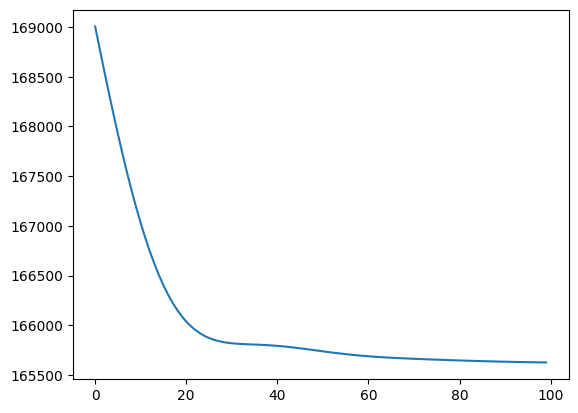

In [35]:
plt.plot(loss_dynamics_t)

## Results

### Plotting norms

In [36]:
from collections import defaultdict
HLINES = defaultdict(list)

for label in QC_t.hidden_gates_dict:
    sublist = QC_t.hidden_gates_dict[label]
    for idx, gate in enumerate(sublist):
        if label == 'CX' or label == 'Noise-CX':
            HLINES[label].append(util.diamond_norm_2q(gate, default_pure_channels[label], dim))
        elif label == 'M':
            HLINES[label].append(util.get_povm_dist(gate, default_pure_channels[label], dim))
        else:
            HLINES[label].append(util.diamond_norm_1q(gate, default_pure_channels[label], dim))
            
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:gray']

In [37]:
def plot_diamond_norms(ax1, ax2):
    colors_idx = [0, 0]
    
    for key in norms_dict.keys():
        label, idx, norm_type = key

        if label in ['Rx', 'Ry', 'CX', 'U', 'Noise-CX']:
            if (label == 'CX' and idx == 1) or (label == 'Noise-CX' and idx == 1):
                continue
                
            if norm_type == 'i':
                ax1.plot(np.abs(norms_dict[label, idx, norm_type]),
                         label=f'{label}{idx}',
                         color=COLORS[colors_idx[0]])
                ax1.axhline(y=HLINES[label][idx],
                            color=COLORS[colors_idx[0]],
                            linestyle=':')
                colors_idx[0] += 1

            else:
                ax2.plot(np.abs(norms_dict[label, idx, norm_type]),
                         label=f'{label}{idx}',
                         color=COLORS[colors_idx[1]])
                colors_idx[1] += 1
            
    ax1.set_title('Diamond norm(ideal, est)', {"size":18})
    ax1.set_xlabel('Algorithm iteration number', {"size":16})

    ax2.set_title('Diamond norm(true, est)', {"size":18})
    ax2.set_xlabel('Algorithm iteration number', {"size":16})

    ax1.legend(prop={'size': 14})
    ax2.legend(prop={'size': 14})
        
        # ax.set_ylim(0.92, 0.98)
        
def plot_povm_norms(ax1, ax2):
    colors_idx = [0, 0]
    
    for key in norms_dict.keys():
        label, idx, norm_type = key

        if label == 'M':
            if norm_type == 'i':
                ax1.plot(np.abs(norms_dict[label, idx, norm_type]),
                         label=f'{label}{idx}',
                         color=COLORS[colors_idx[0]])
                ax1.axhline(y=HLINES[label][idx],
                            color=COLORS[colors_idx[0]],
                            linestyle=':')
                colors_idx[0] += 1

            else:
                ax2.plot(np.abs(norms_dict[label, idx, norm_type]),
                         label=f'{label}{idx}',
                         color=COLORS[colors_idx[1]])
                colors_idx[1] += 1
            
    ax1.set_title('POVM norm(ideal, est)', {"size":18})
    ax1.set_xlabel('Algorithm iteration number', {"size":16})

    ax2.set_title('POVM norm(true, est)', {"size":18})
    ax2.set_xlabel('Algorithm iteration number', {"size":16})

    ax1.legend(prop={'size': 14})
    ax2.legend(prop={'size': 14})
        
        # ax.set_ylim(0.92, 0.98)

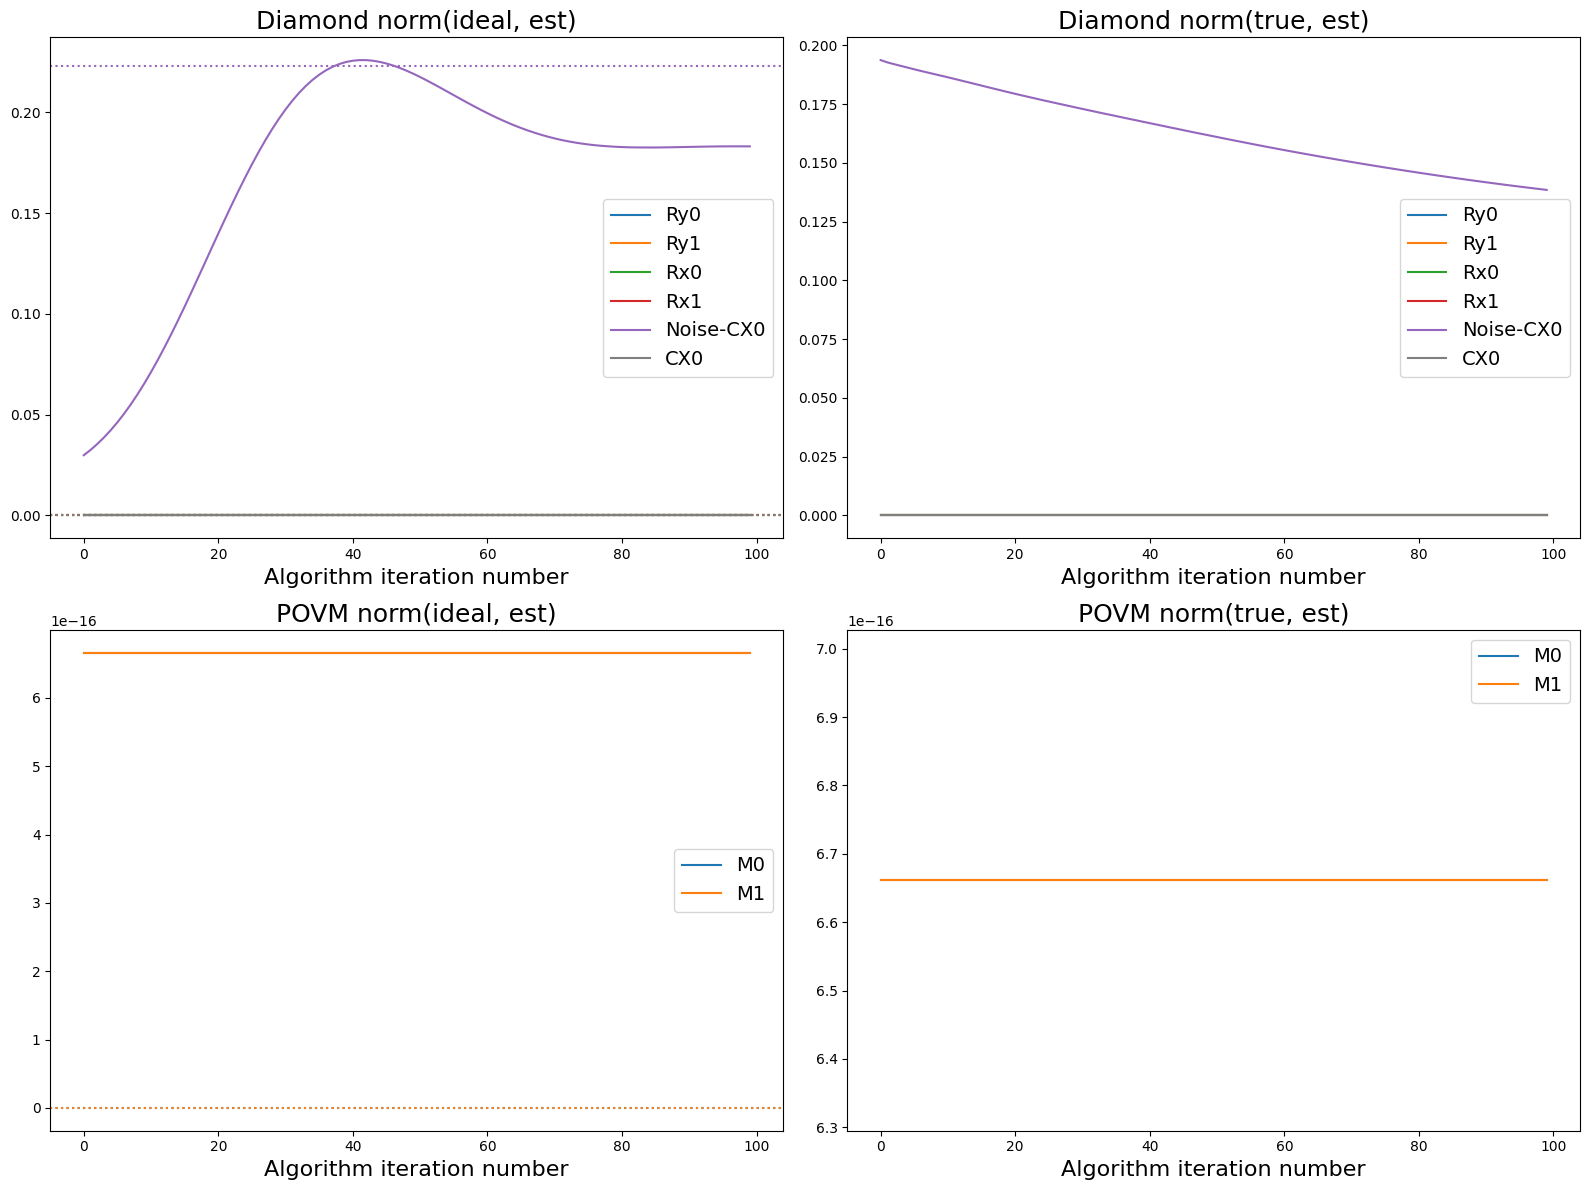

In [38]:
fig, axarr = plt.subplots(2, 2, figsize=(16, 12))
#fig, axarr = plt.subplots(2, figsize=(16, 12))
ax1, ax2, ax3, ax4 = [a for sublist in axarr for a in sublist]
#ax1, ax2 = [a for a in axarr]
plot_diamond_norms(ax1, ax2)
plot_povm_norms(ax3, ax4)
fig.tight_layout()
plt.show()

In [39]:
estim_NCX = c_util.convert_params_to_channel(qgo.manifolds.real_to_complex(QC_t.estimated_gates_dict['Noise-CX'][0]), dim)
real_NCX = QC_t.hidden_gates_dict['Noise-CX'][0]
util.fidel_calc_2q(real_NCX, estim_NCX, dim)

2026-07-23 22:46:37.336973: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


<tf.Tensor: shape=(), dtype=complex128, numpy=(0.9534681434549769+8.459303618586104e-17j)>

### Post-procesing, saving and loading data

You may have a need to conduct experiments on different devices. Or just conveniently save the results somewhere in order to access them later. Fortunately, there's a file `solver/file_management.py` dedicated to such tasks. The code there should be simple and easy to read.

The most important information after an algorithm has done its job now resides in the member `estimated_gates_dict` of a `Solver` class. However, we need to convert it to complex channel form for better readability.

In [24]:
dict_result = get_complex_channel_form(QC_t.estimated_gates_dict)
# print(dict_result)

These are numerical estimations on gates of a quantum processor. Single-qubit gates or SPAM operations have $n$ versions - one for each qubit. Two-qubit gates have $n (n-1)$ versions - one for each pair of qubits. We can save a dict containing this information into a .pickle file, and then extract these tensors somewhere else.

In [25]:
fm.save_tensors_to_file(dict_result, ['tomo-tutorial'], prefix_args=1)

The folder `data\tomo-tutorial` should now appear, with a .pickle file containing the results of the experiment. Of course, you can instantly load them back:

In [26]:
reuploaded_dict = fm.import_tensors_from_file(['tomo-tutorial'], prefix_args=1)
assert reuploaded_dict.keys() == dict_result.keys()
for key in reuploaded_dict:
    assert tf.abs(tf.linalg.norm(reuploaded_dict[key] - dict_result[key])) < 1e-10

Sometimes it is desirable to work with Choi matrices which are familiar to many people instead of some quantum channels denoted in some article. There are ways to convert the gate set into Choi matrices:

In [27]:
choi1 = util.choi_swap_1qchannel(dict_result['Rx'][0])
choi2 = util.choi_swap_2qchannel(dict_result['CX'][0])

It may be useful to save not only the final results as tensors, but also the quantum circuits or generated bit strings. This becomes of critical importance when working with external sources of bit strings (e. g. running only the optimizer with pre-generated data). Below are some examples for working with such information.

In [28]:
fm.save_bitstrings_to_file(QC_t.samples_compressed, ['tomo-tutorial', 'comp'], prefix_args=1)

In [29]:
fm.save_ncon_list_to_file(list(QC_t.tn_templates.values()), ['tomo-tutorial'], prefix_args=1)

In [30]:
fm.save_ncon_list_to_file(circs + [[]], ['tomo-tutorial', 'human-form'], prefix_args=1)

Congratulations, we hope you gained a bit of insight about this humble project and maybe even learned something useful.